# Trabalho Prático 2025/2026 da UC de Aprendizagem Automática

## Diagnóstico de Tumores Cerebrais

### Team MTD:

- **Miguel Grilo | 58387 | IACD**
- **Tiago Ramalho | 58514 | EI**
- **Diogo Belfo | 58706 | EI**

#

# Introdução
Este trabalho prático insere-se na unidade curricular de Aprendizagem Automática e tem como objetivo aplicar técnicas de Machine Learning para resolver um problema real: o diagnóstico de tumores cerebrais. A tarefa consiste em prever se um tumor é benigno ou maligno com base em atributos clínicos e características extraídas de imagens médicas (estatísticas GLCM e medidas associadas).

Para atingir este objetivo, foi disponibilizado um conjunto de dados com exemplos rotulados para treino e um conjunto não rotulado para teste. O trabalho envolve várias etapas fundamentais:
- Análise exploratória e caracterização dos dados;
- Pré-processamento e transformação das variáveis;
- Definição da estratégia de validação para evitar drenagem de informação entre fatias do mesmo paciente;
- Comparação entre diferentes algoritmos e hiperparâmetros;
- Seleção dos melhores modelos e geração de previsões para submissão;
- Discussão dos resultados e conclusões.

Este notebook apresenta não só o código desenvolvido, mas também a fundamentação das escolhas, os resultados obtidos e as conclusões retiradas, garantindo uma visão clara e completa do processo.

#

# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from copy import deepcopy

from sklearn.model_selection import GridSearchCV, GroupShuffleSplit, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, Normalizer, FunctionTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline
#from sklearn.feature_selection import SelectFromModel

# KNN
from sklearn.neighbors import KNeighborsClassifier

# SVM
from sklearn.svm import SVC

# Random Forest, ERT, Gradient Boosting
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

#

# Carregar Dados

In [2]:
train = pd.read_csv('data/treino.csv')
test = pd.read_csv('data/teste.csv')

Este trabalho aborda um problema de **Aprendizagem Supervisionada**. A tarefa específica é a **classificação binária**, cujo objetivo é encontrar um mapeamento entre o espaço de instâncias e o espaço de etiquetas, distinguindo entre tumores **Benignos (0)** e **Malignos (1)**, ou seja, consideramos **Malignos** como **classe positiva**.

#

# Análise Exploratória dos Dados

In [3]:
display(train.head())
display(test.head())

,id,idade,sexo,id_fatia,med_ADC,assimetria,curtose,med1_GLCM,med2_GLCM,var1_GLCM,var2_GLCM,energia_GLCM,entropia_GLCM,contraste_GLCM,homogeneidade_GLCM,correlação_GLCM,proiminência_GLCM,sombra_GLCM,diagnostico
0,1,78,m,5.1,1208.988,11.092,2.774,9.817,9.860,14.637,16.047,0.052,3.507,14.646,0.462,0.523,1.427,1.855,1
1,1,78,m,5.2,897.146,3.044,0.169,7.171,7.482,1.068,2.981,0.081,2.887,3.262,0.571,0.248,1.576,2.076,1
2,1,78,m,5.3,895.563,7.827,2.068,7.133,7.457,2.850,6.443,0.076,3.135,5.941,0.550,0.403,1.809,2.405,1
3,1,78,m,5.4.1,1080.107,3.091,0.832,8.725,9.437,3.680,12.681,0.041,3.728,9.834,0.504,0.515,1.948,2.573,1
4,1,78,m,5.4.2,1025.789,14.450,3.005,8.282,8.736,4.202,12.335,0.067,3.204,9.046,0.548,0.535,2.158,2.920,1


,id,idade,sexo,id_fatia,med_ADC,assimetria,curtose,med1_GLCM,med2_GLCM,var1_GLCM,var2_GLCM,energia_GLCM,entropia_GLCM,contraste_GLCM,homogeneidade_GLCM,correlação_GLCM,proiminência_GLCM,sombra_GLCM
0,187,48,f,2.1,1204.118,3.054,-0.568,9.853,9.860,0.949,1.076,0.095,2.600,1.081,0.645,0.467,-0.599,-1.306
1,187,48,f,2.3,1233.333,2.763,0.784,9.958,10.542,1.957,2.561,0.111,2.456,1.542,0.604,0.741,1.116,1.367
2,187,48,f,2.4,1168.261,3.142,-0.147,9.565,9.641,0.941,1.100,0.099,2.534,1.293,0.601,0.370,0.672,1.370
3,187,48,f,2.5,1019.545,2.074,0.336,8.212,8.402,0.591,0.846,0.117,2.315,0.962,0.664,0.361,0.920,1.409
4,187,48,f,2.6,1153.917,2.876,0.905,9.333,9.958,0.889,2.248,0.161,2.036,2.000,0.525,0.540,1.596,1.911


- Verificamos a existência de IDs de pacientes duplicados então precisamos realizar a separação pelos conjuntos de treino e validação(treino) de modo a **não separar exemplos do mesmo `'id'`** entre os conjuntos de treino e validação(treino), garantindo que permanecem no mesmo conjunto e **não provocam drenagem de informação** durante o `GridSearchCV`.

In [4]:
print("Dataset de Treino:", train.shape)
print("Dataset de Teste:", test.shape)

Dataset de Treino: (1393, 19)
Dataset de Teste: (400, 18)


### **Análise de Instâncias:**
- O **dataset de treino** conta com 1393 exemplos e 19 features (com `'diagnostico'`) antes das transformações.
- O **dataset de teste** conta com 400 exemplos e 18 features (sem `'diagnostico'`) antes das transformações.

Cada objeto é descrito por atributos que funcionam como variáveis preditivas para o diagnóstico.

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1393 entries, 0 to 1392
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1393 non-null   int64  
 1   idade               1393 non-null   int64  
 2   sexo                1393 non-null   object 
 3   id_fatia            1393 non-null   object 
 4   med_ADC             1393 non-null   float64
 5   assimetria          1393 non-null   float64
 6   curtose             1393 non-null   float64
 7   med1_GLCM           1393 non-null   float64
 8   med2_GLCM           1393 non-null   float64
 9   var1_GLCM           1393 non-null   float64
 10  var2_GLCM           1393 non-null   float64
 11  energia_GLCM        1393 non-null   float64
 12  entropia_GLCM       1393 non-null   float64
 13  contraste_GLCM      1393 non-null   float64
 14  homogeneidade_GLCM  1393 non-null   float64
 15  correlação_GLCM     1393 non-null   float64
 16  proimi

### **Análise das Features:**
- Verificamos que as features `'id_fatia'` e `'sexo'` são do tipo object, logo necessitam transformação para o tipo contínuo, porém `'id_fatia'` não possui poder preditivo, logo não será transformada, mas sim excluída das features para evitar ruído, tal como a feature `'id'`.
- O atributo `'sexo'` será mapeado para valores binários (0 e 1).

# Transformação dos Dados

## Conjunto de Treino

In [6]:
# Transformação da feature 'sexo' em formato binário
train["sexo"] = train["sexo"].map({"f": 0, "m": 1})

In [7]:
# Drop das colunas indesejadas no treino do modelo
X_train = train.drop(columns=["id_fatia", "id", "diagnostico"])
# Etiquetas
y_train = train["diagnostico"]

In [8]:
# Confirmar que a transformação da feature 'sexo' foi realizada com sucesso,
# Assim como o drop das colunas indesejadas no treino do modelo
display(X_train.head(10))

,idade,sexo,med_ADC,assimetria,curtose,med1_GLCM,med2_GLCM,var1_GLCM,var2_GLCM,energia_GLCM,entropia_GLCM,contraste_GLCM,homogeneidade_GLCM,correlação_GLCM,proiminência_GLCM,sombra_GLCM
0,78,1,1208.988,11.092,2.774,9.817,9.860,14.637,16.047,0.052,3.507,14.646,0.462,0.523,1.427,1.855
1,78,1,897.146,3.044,0.169,7.171,7.482,1.068,2.981,0.081,2.887,3.262,0.571,0.248,1.576,2.076
2,78,1,895.563,7.827,2.068,7.133,7.457,2.850,6.443,0.076,3.135,5.941,0.550,0.403,1.809,2.405
3,78,1,1080.107,3.091,0.832,8.725,9.437,3.680,12.681,0.041,3.728,9.834,0.504,0.515,1.948,2.573
4,78,1,1025.789,14.450,3.005,8.282,8.736,4.202,12.335,0.067,3.204,9.046,0.548,0.535,2.158,2.920
5,78,1,897.220,7.152,1.628,7.159,7.918,1.426,11.533,0.082,3.000,9.796,0.591,0.461,3.055,4.000
6,78,1,888.875,6.032,1.572,7.094,7.930,0.897,10.987,0.097,2.717,9.633,0.592,0.470,3.671,4.725
7,36,0,953.908,8.539,2.045,7.645,8.046,0.725,2.494,0.173,2.234,1.926,0.699,0.541,2.037,2.605
8,36,0,941.400,2.463,0.240,7.600,7.925,0.540,2.282,0.138,2.325,2.225,0.678,0.316,2.335,3.215
9,36,0,950.468,4.526,0.943,7.623,7.834,0.339,0.969,0.185,1.917,1.094,0.715,0.225,1.854,2.547


In [9]:
# Grupos de separação para o StratifiedGroupKFold
grupo = train["id"]

In [10]:
print("Dataset de Teste:", X_train.shape)

Dataset de Teste: (1393, 16)


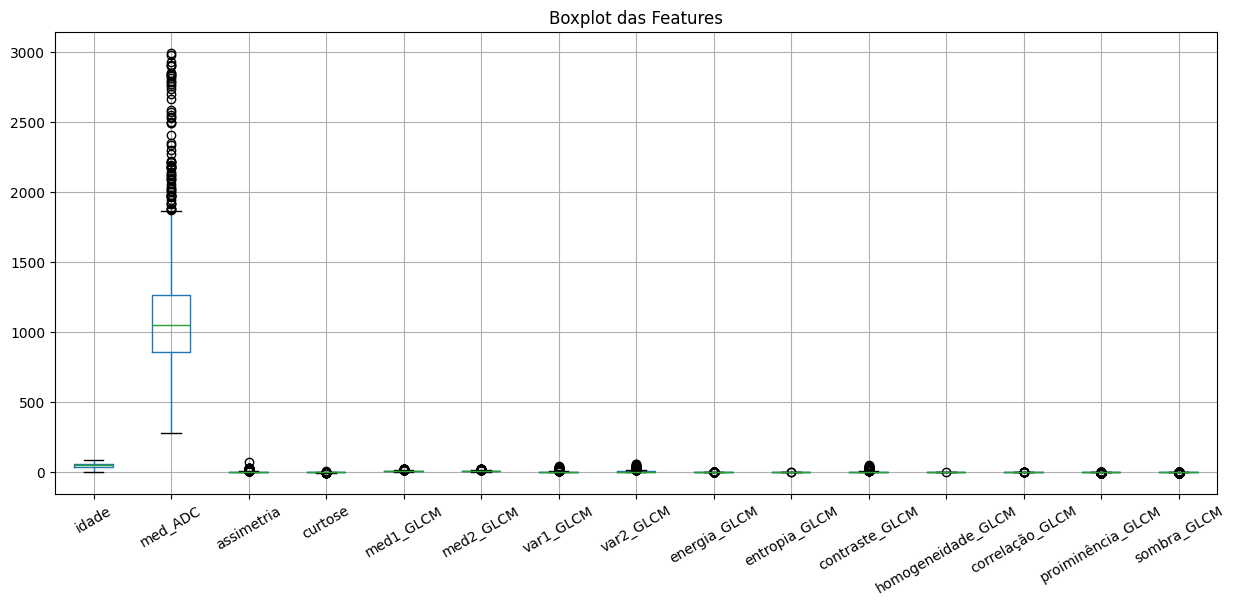

In [11]:
boxplot_set = X_train.drop(columns=['sexo'])
plt.figure(figsize=(15,6))
boxplot_set.boxplot(rot=30)
plt.title("Boxplot das Features")
plt.show()

Portanto, **após as transformações:**
- O dataset de treino (`X_train`) conta com 1393 exemplos e 16 features (sem `'id'`, `'id_fatia'` e `'diagnostico'`).

### **Análise da Escala dos Dados:**
- Verificamos ainda via boxplot a existência de uma ordem de magnitude/escala significativamente superior no atributo `'med_ADC'`, por isso a normalização será um passo essencial de pré-processamento nos algoritmos sensíveis à escala, ou seja, `KNN - KNeighborsClassifier` e `SVM - Support Vector Machines`.

## Conjunto de Teste

In [12]:
# Transformação da feature 'sexo' em formato binário
test["sexo"] = test["sexo"].map({"f": 0, "m": 1})

In [13]:
# Drop das colunas indesejadas na predição
X_test = test.drop(columns=["id", "id_fatia"])

In [14]:
display(X_test.head(10))

,idade,sexo,med_ADC,assimetria,curtose,med1_GLCM,med2_GLCM,var1_GLCM,var2_GLCM,energia_GLCM,entropia_GLCM,contraste_GLCM,homogeneidade_GLCM,correlação_GLCM,proiminência_GLCM,sombra_GLCM
0,48,0,1204.118,3.054,-0.568,9.853,9.860,0.949,1.076,0.095,2.600,1.081,0.645,0.467,-0.599,-1.306
1,48,0,1233.333,2.763,0.784,9.958,10.542,1.957,2.561,0.111,2.456,1.542,0.604,0.741,1.116,1.367
2,48,0,1168.261,3.142,-0.147,9.565,9.641,0.941,1.100,0.099,2.534,1.293,0.601,0.370,0.672,1.370
3,48,0,1019.545,2.074,0.336,8.212,8.402,0.591,0.846,0.117,2.315,0.962,0.664,0.361,0.920,1.409
4,48,0,1153.917,2.876,0.905,9.333,9.958,0.889,2.248,0.161,2.036,2.000,0.525,0.540,1.596,1.911
5,48,0,1064.387,2.343,-0.535,8.645,8.726,1.519,1.780,0.070,2.831,1.742,0.535,0.475,-0.642,-1.274
6,48,0,1075.514,2.152,-0.277,8.743,8.821,1.734,2.204,0.055,3.063,1.621,0.549,0.594,0.412,1.298
7,36,1,1459.866,5.631,1.475,11.963,12.137,10.938,11.722,0.022,4.167,8.534,0.390,0.625,1.187,1.578
8,36,1,1333.119,3.260,0.850,10.847,11.720,6.095,9.795,0.021,4.109,10.636,0.344,0.389,1.256,1.603
9,33,1,1271.825,6.148,0.743,10.386,10.860,2.553,3.173,0.048,3.270,3.132,0.502,0.495,1.176,1.665


In [15]:
print("Dataset de Teste:", X_test.shape)

Dataset de Teste: (400, 16)


Portanto, **após as transformações:**
- O dataset de teste (`X_test`) conta com 400 exemplos e 16 features (sem `'id'`, `'id_fatia'` e `'diagnostico'`).

# Análise Exploratória Após Transformações

In [16]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1393 entries, 0 to 1392
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   idade               1393 non-null   int64  
 1   sexo                1393 non-null   int64  
 2   med_ADC             1393 non-null   float64
 3   assimetria          1393 non-null   float64
 4   curtose             1393 non-null   float64
 5   med1_GLCM           1393 non-null   float64
 6   med2_GLCM           1393 non-null   float64
 7   var1_GLCM           1393 non-null   float64
 8   var2_GLCM           1393 non-null   float64
 9   energia_GLCM        1393 non-null   float64
 10  entropia_GLCM       1393 non-null   float64
 11  contraste_GLCM      1393 non-null   float64
 12  homogeneidade_GLCM  1393 non-null   float64
 13  correlação_GLCM     1393 non-null   float64
 14  proiminência_GLCM   1393 non-null   float64
 15  sombra_GLCM         1393 non-null   float64
dtypes: flo

- Verificamos que todas as features são contínuas então estão **preparadas para serem variáveis preditoras** para os nossos modelos.

,Contagem,Proporção
Classe,,
Benigno,635,45.6%
Maligno,758,54.4%


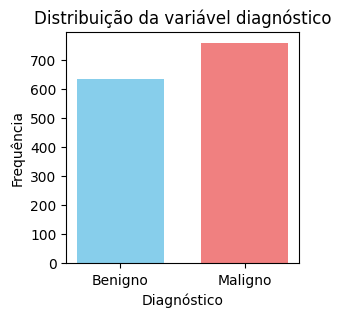

In [17]:
contagem = train['diagnostico'].value_counts().to_dict()
classe0 = contagem[0]
classe1 = contagem[1]
prop_classe0 = (contagem[0]/train.shape[0])
prop_classe1 = (contagem[1]/train.shape[0])

nomes_classes = ['Benigno', 'Maligno']
classes = [classe0, classe1]
proporcoes = [prop_classe0, prop_classe1]
resultados = pd.DataFrame({
    "Classe": nomes_classes,
    "Contagem": classes,
    "Proporção": [f"{p:.1%}" for p in proporcoes]
}).set_index("Classe")
display(resultados)


plt.figure(figsize=(3,3))
counts = train['diagnostico'].value_counts().sort_index()
plt.bar(counts.index, counts.values, width=0.7, color=['skyblue', 'lightcoral'])
plt.xlabel('Diagnóstico')
plt.ylabel('Frequência')
plt.title('Distribuição da variável diagnóstico')
plt.xticks([0, 1], ['Benigno', 'Maligno'])
plt.show()

### **Análise da Distribuição dos Dados por Classe:**

Após realização da análise exploratória dos dados verificamos que os dados estão **aproximadamente balanceados/equilibrados** e a classe positiva é a classe maioritária.
- **Classe 0 (Benigno):** 46%
- **Classe 1 (Maligno):** 54%

#

# Settings e Funções

In [18]:
# Inicia a list para todos os melhores modelos e métricas de cada método e os seus nomes
melhores_modelos = []
melhores_modelos_names = []
melhores_f1_val = []
melhor_f1_train = []    
melhores_overfitting = []

In [19]:
# Setting para dar display das tabelas sem omitir dados das colunas
pd.set_option('display.max_colwidth', None)

## Construção e Avaliação do Melhor Modelo

In [20]:
# Função responsável pela construção e avaliação do modelo ### REMOVER IMPORTÂNCIAS NÃO SIGNIFICATIVAS ###
def modelo(metodo, string_metodo, params_grid, scaler=None): # importancia_features=False, threshold=0.05
    string_pipeline = string_metodo

    if scaler is None:
        scaler = FunctionTransformer(lambda x: x)
    #    string_metodo = "no_scaler_" + string_metodo
    #elif isinstance(scaler, StandardScaler):
    #    string_metodo = "standard_" + string_metodo

    pipeline = Pipeline([
        ('scaler', scaler),
        (string_pipeline, metodo)
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=params_grid,
        cv=sgf,
        scoring="f1",
        n_jobs=-1,
        return_train_score=True
    )
    grid_search.fit(X_train, y_train, groups=grupo)

    # Melhor modelo
    melhor_modelo = grid_search.best_estimator_

    ###
    # Implementação das Feature Importances (Bloco seguinte) -> Não utilizado pois apresentava pior desempenho nos modelos
    ###
    
    # Arrays para a tabela final:
    # Índice da melhor combinação
    melhor_indice = grid_search.best_index_
    # Extrair métricas do melhor
    melhor_mean_train = grid_search.cv_results_['mean_train_score'][melhor_indice]
    melhor_mean_val = grid_search.cv_results_['mean_test_score'][melhor_indice]
    melhor_overfit = melhor_mean_train - melhor_mean_val

    melhores_modelos_names.append(string_metodo)
    melhores_modelos.append(melhor_modelo)
    melhores_f1_val.append(grid_search.best_score_)
    melhor_f1_train.append(melhor_mean_train)
    melhores_overfitting.append(melhor_overfit)

    print("Melhores parâmetros:", grid_search.best_params_)
    print(f"Melhor F1 (Val): {melhores_f1_val[-1]:.2f}")

    resultados_df = pd.DataFrame(grid_search.cv_results_)
    resultados_df = resultados_df[["params", "mean_train_score", "mean_test_score", "rank_test_score"]]
    resultados_df["overfitting"] = (resultados_df["mean_train_score"] - resultados_df["mean_test_score"])
    resultados_df = resultados_df.sort_values(by="rank_test_score")

    display(resultados_df.head())
    
    return melhor_modelo

A **função `modelo`** foi desenvolvida para facilitar a construção, otimização e avaliação de modelos. Esta função organiza o fluxo de trabalho em três componentes principais: o Pipeline, o GridSearchCV e a métrica de scoring F1.

- O **Pipeline** é utilizado para encadear sequencialmente os passos de processamento de dados. Na função, ele agrupa um transformador de escala (`scaler`) e o algoritmo de classificação (`metodo`). Esta estrutura garante que as transformações, como o `StandardScaler`, sejam aplicadas corretamente tanto nos dados de treino quanto nos de validação, evitando erros de escala que podem prejudicar modelos geométricos como o `KNN` ou o `SVM`. Caso não seja necessário um escalonador, a função utiliza um FunctionTransformer neutro para manter a consistência do fluxo.

- A **otimização dos hiper-parâmetros** é gerida pelo **`GridSearchCV`**, que realiza uma pesquisa exaustiva através de todas as combinações definidas no dicionário `params_grid`. Este método integra a validação cruzada (usando o objeto `sgf`), o que significa que o modelo é treinado e testado em múltiplas divisões dos dados **para garantir que os resultados são robustos e não dependem de uma partição específica**. A função também utiliza o parâmetro `groups=grupo` para assegurar que instâncias pertencentes ao mesmo paciente não sejam separadas entre treino e validação, **prevenindo a drenagem de informação**.

- A métrica de otimização escolhida para orientar a pesquisa é o **F1-score**. Esta medida é a média harmónica entre a precisão (confiança nas previsões positivas) e a cobertura (capacidade de encontrar todos os casos positivos). O uso do F1 é preferível à exatidão simples em contextos onde os dados não estão perfeitamente balanceados ou onde existe uma necessidade clínica de equilibrar a deteção de doenças (evitar falsos negativos) com a minimização de diagnósticos errados (evitar falsos positivos).

- No final da execução, a função identifica o melhor_modelo (`best_estimator_`) e calcula automaticamente o nível de overfitting. Este valor é determinado pela diferença entre o desempenho médio no conjunto de treino e no conjunto de validação (mean_train_score - mean_test_score), permitindo identificar se o modelo está a memorizar os dados de treino em vez de aprender padrões que generalizem para novos exemplos.

```python
    # FEATURE IMPORTANCE (Por omissão = False)
       if (importancia_features and hasattr(melhor_modelo.named_steps[string_pipeline], "feature_importances_")):
            selector = SelectFromModel(
                melhor_modelo.named_steps[string_pipeline],
                threshold=threshold)
            pipeline_f = Pipeline([
                ('scaler', scaler),
                ('selector', selector),
                (string_pipeline, metodo)])
            grid_search_f = GridSearchCV(
                estimator=pipeline_f,
                param_grid=params_grid,
                cv=sgf,
                scoring="f1",
                n_jobs=-1,
                return_train_score=True)
            grid_search_f.fit(X_train, y_train, groups=grupo)
            grid_search = grid_search_f
            melhor_modelo = grid_search.best_estimator_
```

Este código utiliza `SelectFromModel` para identificar e remover atributos não significativos com base na sua importância preditiva. Contudo, embora desenhado para simplificar o modelo, este bloco não foi implementado na versão final do projeto. A análise experimental demonstrou que a exclusão destas características piorava o desempenho global (F1-score) comparativamente à utilização do conjunto total de dados.

## Classification Report

In [21]:
def display_classification_report(metodo, valor=0.5):
    y_pred = metodo.predict_proba(X_train)[:,1]
    y_pred = (y_pred >= valor).astype(int)
    
    report_dict = classification_report(y_train, y_pred, target_names=['Benigno', 'Maligno'], output_dict=True, zero_division=0)

    df = pd.DataFrame(report_dict).T
    df = df.loc[['Benigno', 'Maligno', 'accuracy'], ['precision', 'recall', 'f1-score']].round(2)
    df = df.rename(index={'accuracy': 'Exatidão'}, columns={'precision': 'Precisão', 'recall': 'Cobertura','f1-score': 'F1-Score'
    })

    return df

## Matriz de Confusão

In [22]:
def matriz_confusao(modelo, X_test, y_test, nome_modelo, valor=0.5):
    # Previsões
    y_pred = modelo.predict_proba(X_test)[:,1]
    y_pred = (y_pred >= valor).astype(int)
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    
    # Exibição
    plt.figure(figsize=(10, 3))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
    disp.plot(cmap="Purples", ax=plt.gca())
        
    plt.xlabel("Predição")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusão — {nome_modelo}")
    plt.show()

## Previsão Conj. Teste

### Predict_Proba

In [23]:
# Função responsável pela predição no conjunto de teste e retornar o csv com os resultados
def modelo_pred_proba(modelo, output_file, valor=0.5):    
    probs_test = modelo.predict_proba(X_test)[:,1]
    df_preds = pd.DataFrame({
        "id": test["id"],
        "prob_classe_1": probs_test
    })
    
    submit = df_preds.groupby("id")["prob_classe_1"].mean().reset_index()
    submit["diagnostico"] = (submit["prob_classe_1"] >= valor).astype(int)
    submit.drop(columns="prob_classe_1", inplace=True)
        
    submit_index = submit.set_index("id")
    submit.to_csv(output_file+".csv", index=False)

    print('Predição Final por Paciente:')
    display(submit_index)
    
    contagem = submit["diagnostico"].value_counts()
    print("\nContagem de diagnósticos:")
    print(f"  Benigno (0): {contagem.get(0, 0)}")
    print(f"  Maligno (1): {contagem.get(1, 0)}")

Esta função gera predições para o conjunto de teste, calculando a probabilidade média por paciente (`id`). Aplica um limiar (*0.5 por omissão*) para definir o diagnóstico final, exporta os resultados para CSV e apresenta a contagem das classes Benigno e Maligno.

### Predict

```python
# Função responsável pela predição no conjunto de teste e retornar o csv com os resultados
def modelo_pred(modelo, output_file, valor=0.5):    
    probs_test = modelo.predict(X_test)
    df_preds = pd.DataFrame({
        "id": test["id"],
        "prob_classe_1": probs_test
    })
    
    submit = df_preds.groupby("id")["prob_classe_1"].mean().reset_index()
    submit["diagnostico"] = (submit["prob_classe_1"] >= valor).astype(int)
    submit.drop(columns="prob_classe_1", inplace=True)
    
    
    submit_index = submit.set_index("id")
    submit.to_csv(output_file+".csv", index=False)

    print('Predição Final por Paciente:')
    display(submit_index)
    
    contagem = submit["diagnostico"].value_counts()
    print("\nContagem de diagnósticos:")
    print(f"Benigno (0): {contagem.get(0, 0)}")
    print(f"Maligno (1): {contagem.get(1, 0)}")
```

O método Predict não foi utilizado, visto que em comparação com **Predict Proba**, este último **apresenta melhor capacidade de predição**.

#

## StratifiedGroupKFold

In [24]:
sgf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

- Realizamos a separação com recurso a `StratifiedGroupKFold` 5 pastas. Esta abordagem é a mais robusta para garantir a generalização, pois mantém a proporção das classes e garante  que as instâncias de um mesmo paciente (`'id'`) permaneçam no mesmo conjunto durante o treino e validação, **evitando drenagem de informação**.

#

## Critérios de Seleção e Exclusão de Algoritmos

Para a análise deste conjunto de dados, foram selecionados algoritmos de classificação que se ajustam bem a dados estruturados com múltiplas features contínuas e potenciais interações não lineares entre elas. Os **5 de algoritmos escolhidos** foram **RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, SVC e KNeighborsClassifier**.

- **RandomForestClassifier** e **ExtraTreesClassifier** são robustos a outliers, não requerem normalização e capturam relações complexas entre características de textura.  
- **GradientBoostingClassifier** oferece excelente capacidade de modelação de padrões complexos, embora seja mais sensível à escolha de hiperparâmetros.  
- **SVC** é eficaz em espaços de alta dimensionalidade e pode lidar com relações não lineares, sendo particularmente potente após normalização dos dados.  
- **KNeighborsClassifier** é um método não paramétrico simples que aproveita a proximidade entre exemplos, funcionando bem após normalização.  

Algoritmos como **LinearRegression, Ridge, Lasso** foram descartados, pois são destinados a problemas de regressão. **LogisticRegression** é limitado para capturar interações não lineares complexas, enquanto **DecisionTreeClassifier** apresenta maior variabilidade e risco de overfitting. As **Redes Neuronais** foram descartadas pois, apesar de serem modelos de aprendizagem supervisionada potentes, o conjunto de dados é relativamente pequeno para as exigências deste tipo de arquitetura, que geralmente requer volumes de dados enormes para evitar o sobre-ajustamento e garantir uma boa generalização. Por fim, os **algoritmos de aprendizagem não supervisionada** foram descartados de imediato, visto que temos as classes à disposição, não faria sentido não serem usados para benefício do estudo, ainda para mais tendo um conjunto de dados relativamente pequeno.

Esta seleção garante um equilíbrio entre robustez, capacidade de modelar padrões complexos e generalização para novos exemplos.

#

## Critérios de Seleção e Exclusão de Scaler

A escolha de utilizar `scaler` depende fundamentalmente da natureza de cada algoritmo. 

### **Uso de StandardScaler:**

- Os algoritmos **KNN (K-Nearest Neighbors)** e **SVM (Support Vector Machines)** são classificados como modelos geométricos.
  - **KNN** - Este algoritmo baseia-se no cálculo de distâncias (como a Euclidiana ou Manhattan) entre instâncias para realizar previsões. Se os atributos estiverem em escalas diferentes, um atributo com valores numericamente maiores (como o `'med_ADC'`) dominará o cálculo da distância, tornando os outros atributos irrelevantes.
  - **SVM** - É extremamente sensível à escala dos dados porque tenta encontrar um hiperplano com a maior margem de separação possível. Atributos com ordens de magnitude distintas prejudicam a formação desta fronteira de decisão, levando a modelos ineficientes ou ao sobre-ajustamento.
  
### **Sem Scaler:**

- Modelos baseados em árvores, como **Random Forest**, **Extra Trees** e **Gradient Boosting**, utilizam uma lógica de "divisão-e-conquista".
  - **Invariância:** Estes algoritmos são invariantes à escala pois utilizam limiares individuais por atributo. Enquanto Random Forest e Gradient Boosting procuram o melhor ponto de corte, o ERT escolhe-o aleatoriamente.
  - **Performance:** Nos testes práticos realizados, o uso de scalers nestes modelos resultou num pior desempenho em comparação com o uso dos dados originais. Por isso, o `scaler` é opcional e foi descartado para estes casos.

### **Preferência pelo StandardScaler**

Embora existam várias técnicas de pré-processamento, o `StandardScaler` (que garante média 0 e variância 1) foi preferido pois:
- **Robustez:** Ao contrário do `MinMaxScaler`, que comprime os dados entre 0 e 1 e é muito afetado por valores extremos, o `StandardScaler` mantém a distribuição relativa dos dados.
- **Resultados:** Nas experiências realizadas (especialmente com o KNN), o `StandardScaler` apresentou um desempenho superior ao `MinMaxScaler` e a outros métodos, garantindo um melhor equilíbrio entre os resultados de treino e validação.
- **Comparação:** O `RobustScaler` (baseado em medianas) é útil apenas quando existem muitos outliers que não devem ser considerados, enquanto o `Normalizer` foca-se na direção do vetor, o que não é ideal para o nosso conjunto de dados.

#

# KNN - KNeighborsClassifier

## Construção e Validação do Modelo:

In [25]:
k_sqrt = int(np.sqrt(X_train.shape[0]))
neighbors = range(k_sqrt - 5, k_sqrt + 6)

params_grid_knn = {
    "knn__n_neighbors": neighbors,
    "knn__weights":     ["uniform"],
    "knn__algorithm":   ["auto", "brute"],
    #"knn__algorithm":   ["ball_tree", "kd_tree"],
    #"knn__leaf_size":   [5, 10, 15, 20],
    "knn__metric":      ["euclidean", "manhattan"]
}

Este código configura o **KNN**, um modelo geométrico. O hiper-parâmetro `n_neighbors` controla a complexidade (valores baixos arriscam sobre-ajustamento e valores altos sub-ajustamento), a grelha testada baseia-se na raiz quadrada do total de instâncias. `weights` (`"uniform"`) trata os vizinhos com igual importância. `algorithm` define a estratégia de busca (`"auto"` ou `"brute"`). A `metric` (`"euclidean"` ou `"manhattan"`) determina como medir a distância entre pontos. 

***Nota:** O modelo exige normalização prévia por ser sensível à escala.*

In [26]:
melhor_modelo_knn_standard = modelo(KNeighborsClassifier(), 'knn', params_grid_knn, StandardScaler())

Melhores parâmetros: {'knn__algorithm': 'auto', 'knn__metric': 'euclidean', 'knn__n_neighbors': 37, 'knn__weights': 'uniform'}
Melhor F1 (Val): 0.73


,params,mean_train_score,mean_test_score,rank_test_score,overfitting
5,"{'knn__algorithm': 'auto', 'knn__metric': 'euclidean', 'knn__n_neighbors': 37, 'knn__weights': 'uniform'}",0.808823,0.726586,1,0.082237
27,"{'knn__algorithm': 'brute', 'knn__metric': 'euclidean', 'knn__n_neighbors': 37, 'knn__weights': 'uniform'}",0.808823,0.726586,1,0.082237
20,"{'knn__algorithm': 'auto', 'knn__metric': 'manhattan', 'knn__n_neighbors': 41, 'knn__weights': 'uniform'}",0.812450,0.726341,3,0.086110
42,"{'knn__algorithm': 'brute', 'knn__metric': 'manhattan', 'knn__n_neighbors': 41, 'knn__weights': 'uniform'}",0.812450,0.726341,3,0.086110
25,"{'knn__algorithm': 'brute', 'knn__metric': 'euclidean', 'knn__n_neighbors': 35, 'knn__weights': 'uniform'}",0.812095,0.724875,5,0.087220


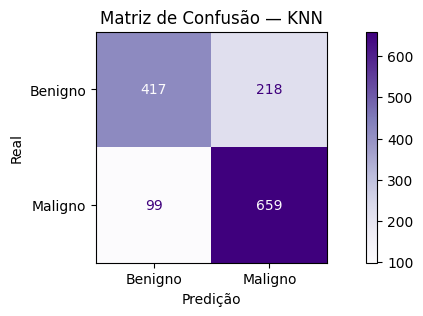

,Precisão,Cobertura,F1-Score
Benigno,0.81,0.66,0.72
Maligno,0.75,0.87,0.81
Exatidão,0.77,0.77,0.77


In [27]:
matriz_confusao(melhor_modelo_knn_standard, X_train, y_train, 'KNN')
display_classification_report(melhor_modelo_knn_standard)

O modelo **KNN** obteve 77% de exatidão, com boa cobertura para Maligno (0,87), mas menor para Benigno (0,66), indicando mais falsos positivos.

## Avaliação do Modelo 

In [28]:
modelo_pred_proba(melhor_modelo_knn_standard, 'submit_knn_standard')

Predição Final por Paciente:


,diagnostico
id,
187,1
188,0
189,0
190,0
191,0
...,...
246,1
247,1
248,1



Contagem de diagnósticos:
  Benigno (0): 25
  Maligno (1): 39


#

# SVM - Support Vector Machines

## Construção e Validação do Modelo:

In [29]:
params_grid_svm = {
    "svm__C":                       [0.1, 1, 10], 
    "svm__kernel":                  ["poly"],
    "svm__degree":                  [2, 3, 4],
    "svm__gamma":                   ["scale", "auto"],
    "svm__probability":             [True],
    "svm__class_weight":            [None, "balanced"],
    #"svm__max_iter":                [1000, 2000, 5000, 10000],
}

Estes parâmetros configuram o **SVM** de modo a regular a complexidade do modelo: `C` controla a regularização, onde valores altos aumentam o ajuste individual aos dados. O `kernel` `'poly'` com `degree` mapeia relações não lineares em dimensões superiores. `Gamma` ajusta a largura da influência de cada instância na fronteira de decisão. `class_weight` testa se compensa balancear o desequilíbrio entre classes. 

***Nota:** Este modelo exige obrigatoriamente normalização (StandardScaler) por ser sensível à escala.*

In [30]:
melhor_modelo_svm_standard = modelo(SVC(probability=True, random_state=0), 'svm', params_grid_svm, StandardScaler())

Melhores parâmetros: {'svm__C': 1, 'svm__class_weight': None, 'svm__degree': 3, 'svm__gamma': 'scale', 'svm__kernel': 'poly', 'svm__probability': True}
Melhor F1 (Val): 0.76


,params,mean_train_score,mean_test_score,rank_test_score,overfitting
15,"{'svm__C': 1, 'svm__class_weight': None, 'svm__degree': 3, 'svm__gamma': 'auto', 'svm__kernel': 'poly', 'svm__probability': True}",0.825475,0.757354,1,0.068120
14,"{'svm__C': 1, 'svm__class_weight': None, 'svm__degree': 3, 'svm__gamma': 'scale', 'svm__kernel': 'poly', 'svm__probability': True}",0.825475,0.757354,1,0.068120
20,"{'svm__C': 1, 'svm__class_weight': 'balanced', 'svm__degree': 3, 'svm__gamma': 'scale', 'svm__kernel': 'poly', 'svm__probability': True}",0.829988,0.756637,3,0.073352
21,"{'svm__C': 1, 'svm__class_weight': 'balanced', 'svm__degree': 3, 'svm__gamma': 'auto', 'svm__kernel': 'poly', 'svm__probability': True}",0.829988,0.756637,3,0.073352
9,"{'svm__C': 0.1, 'svm__class_weight': 'balanced', 'svm__degree': 3, 'svm__gamma': 'auto', 'svm__kernel': 'poly', 'svm__probability': True}",0.782467,0.753745,5,0.028722


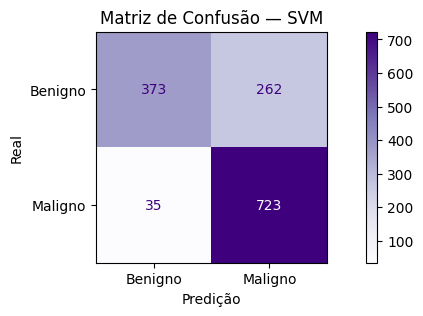

,Precisão,Cobertura,F1-Score
Benigno,0.91,0.59,0.72
Maligno,0.73,0.95,0.83
Exatidão,0.79,0.79,0.79


In [31]:
matriz_confusao(melhor_modelo_svm_standard, X_train, y_train, 'SVM')
display_classification_report(melhor_modelo_svm_standard)

O modelo **SVM** obteve 79% de exatidão, com excelente cobertura para Maligno (0,95) e baixa cobertura para Benigno (0,59), indicando tendência a classificar malignos corretamente.

## Avaliação do Modelo 

In [32]:
modelo_pred_proba(melhor_modelo_svm_standard, 'submit_svm_standard')

Predição Final por Paciente:


,diagnostico
id,
187,1
188,1
189,0
190,0
191,0
...,...
246,1
247,1
248,1



Contagem de diagnósticos:
  Benigno (0): 22
  Maligno (1): 42


#

# Random Forest - RandomForestClassifier

## Construção e Validação do Modelo:

In [33]:
params_grid_rf = {
    "rfc__n_estimators":      range(20, 101, 20),
    "rfc__criterion":         ["entropy"],
    "rfc__max_depth":         [3, 5, 10],
    #"rfc__min_samples_split": [2],
    "rfc__min_samples_leaf":  [4, 5],
    "rfc__max_features":      ["sqrt"],
    "rfc__bootstrap":         [True],
    "rfc__class_weight":      [None],
    "rfc__max_samples":       [0.8, None]
}

Esta configuração de **Random Forest** foca na estabilidade e no controlo da complexidade. O `n_estimators` define o número de árvores; quanto mais modelos, maior a robustez do comité. O `criterion` utiliza a `"entropy"` para medir a impureza das divisões. Hiper-parâmetros como `max_depth` e `min_samples_leaf` aplicam pré-poda, limitando o crescimento das árvores para evitar o sobre-ajustamento. O `max_features` (`"sqrt"`) garante a diversidade ao testar subconjuntos aleatórios de atributos. Já o `bootstrap` e `max_samples` implementam a estratégia de bagging, reduzindo a variância através de amostras aleatórias com reposição.

In [34]:
melhor_modelo_rf_no_scaler = modelo(RandomForestClassifier(random_state=0), 'rfc', params_grid_rf, None)

Melhores parâmetros: {'rfc__bootstrap': True, 'rfc__class_weight': None, 'rfc__criterion': 'entropy', 'rfc__max_depth': 3, 'rfc__max_features': 'sqrt', 'rfc__max_samples': None, 'rfc__min_samples_leaf': 4, 'rfc__n_estimators': 60}
Melhor F1 (Val): 0.74


,params,mean_train_score,mean_test_score,rank_test_score,overfitting
12,"{'rfc__bootstrap': True, 'rfc__class_weight': None, 'rfc__criterion': 'entropy', 'rfc__max_depth': 3, 'rfc__max_features': 'sqrt', 'rfc__max_samples': None, 'rfc__min_samples_leaf': 4, 'rfc__n_estimators': 60}",0.805765,0.739394,1,0.066371
17,"{'rfc__bootstrap': True, 'rfc__class_weight': None, 'rfc__criterion': 'entropy', 'rfc__max_depth': 3, 'rfc__max_features': 'sqrt', 'rfc__max_samples': None, 'rfc__min_samples_leaf': 5, 'rfc__n_estimators': 60}",0.804889,0.738852,2,0.066038
13,"{'rfc__bootstrap': True, 'rfc__class_weight': None, 'rfc__criterion': 'entropy', 'rfc__max_depth': 3, 'rfc__max_features': 'sqrt', 'rfc__max_samples': None, 'rfc__min_samples_leaf': 4, 'rfc__n_estimators': 80}",0.803416,0.737790,3,0.065626
18,"{'rfc__bootstrap': True, 'rfc__class_weight': None, 'rfc__criterion': 'entropy', 'rfc__max_depth': 3, 'rfc__max_features': 'sqrt', 'rfc__max_samples': None, 'rfc__min_samples_leaf': 5, 'rfc__n_estimators': 80}",0.803191,0.735594,4,0.067597
3,"{'rfc__bootstrap': True, 'rfc__class_weight': None, 'rfc__criterion': 'entropy', 'rfc__max_depth': 3, 'rfc__max_features': 'sqrt', 'rfc__max_samples': 0.8, 'rfc__min_samples_leaf': 4, 'rfc__n_estimators': 80}",0.800907,0.731649,5,0.069258


```python
melhor_modelo_rf_standard = modelo(RandomForestClassifier(random_state=0), 'rfc', params_grid_rf, StandardScaler())
# O uso do Scaler nas árvores do modelo Random Forest obtém pior desempenho em comparação com o uso dos dados originais. 
# Assim, sendo opcional, optamos então por não usar Scaler.
```

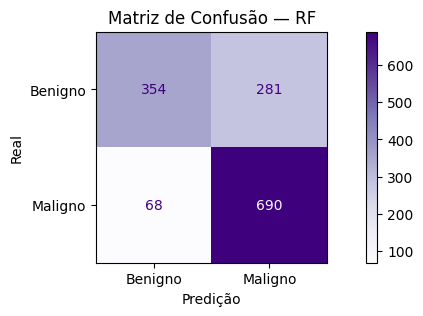

,Precisão,Cobertura,F1-Score
Benigno,0.84,0.56,0.67
Maligno,0.71,0.91,0.80
Exatidão,0.75,0.75,0.75


In [35]:
matriz_confusao(melhor_modelo_rf_no_scaler, X_train, y_train, 'RF')
display_classification_report(melhor_modelo_rf_no_scaler)

O modelo **Random Forest** atingiu 75% de exatidão, com alta cobertura para Maligno (0,91) e baixa para Benigno (0,56), indicando tendência a priorizar deteção de malignos.

## Avaliação do Modelo 

In [36]:
modelo_pred_proba(melhor_modelo_rf_no_scaler, 'submit_rf_no_scaler')

Predição Final por Paciente:


,diagnostico
id,
187,1
188,0
189,1
190,1
191,0
...,...
246,1
247,1
248,1



Contagem de diagnósticos:
  Benigno (0): 24
  Maligno (1): 40


#

# Extremely Randomized Trees (ERT) - ExtraTreesClassifier 

## Construção e Validação do Modelo:

In [37]:
params_grid_ert = {
    "ert__n_estimators":      [50, 75, 100],
    "ert__max_depth":         [3, 4],
    "ert__min_samples_leaf":  [2, 3],
    "ert__min_samples_split": [4, 5, 6],
    "ert__max_features":      ["sqrt"],
    "ert__criterion":         ["gini"],
    "ert__class_weight":      [None],
    "ert__bootstrap":         [True],
    "ert__max_leaf_nodes":    [40]
}

Esta configuração de **Extremely Randomized Trees (ERT)** introduz aleatoriedade adicional nos pontos de corte das árvores, tornando o modelo menos pesado computacionalmente. O `n_estimators` define o número de árvores no comité para garantir robustez. Hiper-parâmetros como `max_depth`, `min_samples_leaf` e `max_leaf_nodes` aplicam pré-poda, limitando a complexidade do modelo para evitar o sobre-ajustamento. O uso de `max_features` `("sqrt")` promove a diversidade entre as árvores. O `criterion` `"gini"` mede a impureza estatística das divisões, enquanto o `bootstrap` reduz a variância através de amostras aleatórias com reposição.

In [38]:
melhor_modelo_ert_no_scaler = modelo(ExtraTreesClassifier(random_state=0), 'ert', params_grid_ert, None)

Melhores parâmetros: {'ert__bootstrap': True, 'ert__class_weight': None, 'ert__criterion': 'gini', 'ert__max_depth': 4, 'ert__max_features': 'sqrt', 'ert__max_leaf_nodes': 40, 'ert__min_samples_leaf': 2, 'ert__min_samples_split': 6, 'ert__n_estimators': 50}
Melhor F1 (Val): 0.74


,params,mean_train_score,mean_test_score,rank_test_score,overfitting
24,"{'ert__bootstrap': True, 'ert__class_weight': None, 'ert__criterion': 'gini', 'ert__max_depth': 4, 'ert__max_features': 'sqrt', 'ert__max_leaf_nodes': 40, 'ert__min_samples_leaf': 2, 'ert__min_samples_split': 6, 'ert__n_estimators': 50}",0.799116,0.736359,1,0.062757
18,"{'ert__bootstrap': True, 'ert__class_weight': None, 'ert__criterion': 'gini', 'ert__max_depth': 4, 'ert__max_features': 'sqrt', 'ert__max_leaf_nodes': 40, 'ert__min_samples_leaf': 2, 'ert__min_samples_split': 4, 'ert__n_estimators': 50}",0.800113,0.735508,2,0.064605
21,"{'ert__bootstrap': True, 'ert__class_weight': None, 'ert__criterion': 'gini', 'ert__max_depth': 4, 'ert__max_features': 'sqrt', 'ert__max_leaf_nodes': 40, 'ert__min_samples_leaf': 2, 'ert__min_samples_split': 5, 'ert__n_estimators': 50}",0.799715,0.735117,3,0.064598
27,"{'ert__bootstrap': True, 'ert__class_weight': None, 'ert__criterion': 'gini', 'ert__max_depth': 4, 'ert__max_features': 'sqrt', 'ert__max_leaf_nodes': 40, 'ert__min_samples_leaf': 3, 'ert__min_samples_split': 4, 'ert__n_estimators': 50}",0.796960,0.732385,4,0.064575
30,"{'ert__bootstrap': True, 'ert__class_weight': None, 'ert__criterion': 'gini', 'ert__max_depth': 4, 'ert__max_features': 'sqrt', 'ert__max_leaf_nodes': 40, 'ert__min_samples_leaf': 3, 'ert__min_samples_split': 5, 'ert__n_estimators': 50}",0.796960,0.732385,4,0.064575


```python
melhor_modelo_ert_standard = modelo(ExtraTreesClassifier(random_state=0), 'ert', params_grid_ert, StandardScaler())
# O uso do Scaler nas árvores do modelo Extra Trees obtém igual desempenho em comparação com o uso dos dados originais. 
# Assim, sendo opcional, optamos por não usar Scaler do mesmo modo que em Random Forest.
```

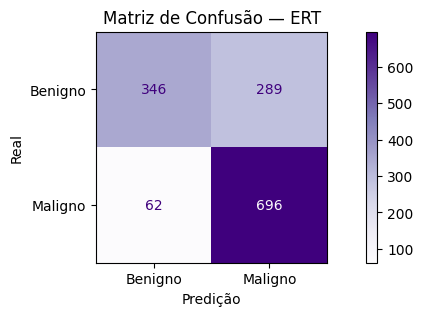

,Precisão,Cobertura,F1-Score
Benigno,0.85,0.54,0.66
Maligno,0.71,0.92,0.80
Exatidão,0.75,0.75,0.75


In [39]:
matriz_confusao(melhor_modelo_ert_no_scaler, X_train, y_train, 'ERT')
display_classification_report(melhor_modelo_ert_no_scaler)

O modelo **ERT** obteve 75% de exatidão, com excelente cobertura para Maligno (0,92) e baixa para Benigno (0,54), indicando tendência a priorizar deteção de malignos.

## Avaliação do Modelo 

In [40]:
modelo_pred_proba(melhor_modelo_ert_no_scaler, 'submit_ert_no_scaler')

Predição Final por Paciente:


,diagnostico
id,
187,1
188,0
189,1
190,0
191,0
...,...
246,1
247,1
248,1



Contagem de diagnósticos:
  Benigno (0): 21
  Maligno (1): 43


#

# Gradient Boosting Machines/Trees - GradientBoostingClassifier

## Construção e Validação do Modelo:

In [41]:
params_grid_gb = {
    "gb__learning_rate":    [0.05, 0.1],
    "gb__n_estimators":     [50],
    "gb__max_depth":        [2, 3],
    "gb__subsample":        [0.8],
    "gb__min_samples_leaf": [1, 2],
    "gb__max_features":     ["sqrt"],
    "gb__n_iter_no_change": [None, 10],
    "gb__tol":              [0.0, 1e-4, 1e-3],
    #"gb__validation_fraction": [0.1]     # default
}

Por fim, a configuração de **Gradient Boosting** foca-se na construção sequencial de árvores, onde cada uma tenta corrigir os erros da anterior. O `learning_rate` controla a intensidade dessas correções, enquanto o `n_estimators` define o número total de modelos. A `max_depth` e o `min_samples_leaf` aplicam uma forte pré-poda para evitar o sobre-ajustamento, dado que o algoritmo é muito sensível à afinação de parâmetros. O `subsample` e o `max_features` introduzem aleatoriedade para melhorar a generalização. `n_iter_no_change` e `tol` permitem a paragem antecipada para otimizar o tempo de treino.

In [42]:
melhor_modelo_gb_no_scaler = modelo(GradientBoostingClassifier(random_state=0), 'gb', params_grid_gb, None)

Melhores parâmetros: {'gb__learning_rate': 0.05, 'gb__max_depth': 3, 'gb__max_features': 'sqrt', 'gb__min_samples_leaf': 1, 'gb__n_estimators': 50, 'gb__n_iter_no_change': 10, 'gb__subsample': 0.8, 'gb__tol': 0.0}
Melhor F1 (Val): 0.74


,params,mean_train_score,mean_test_score,rank_test_score,overfitting
15,"{'gb__learning_rate': 0.05, 'gb__max_depth': 3, 'gb__max_features': 'sqrt', 'gb__min_samples_leaf': 1, 'gb__n_estimators': 50, 'gb__n_iter_no_change': 10, 'gb__subsample': 0.8, 'gb__tol': 0.0}",0.856942,0.739191,1,0.117752
16,"{'gb__learning_rate': 0.05, 'gb__max_depth': 3, 'gb__max_features': 'sqrt', 'gb__min_samples_leaf': 1, 'gb__n_estimators': 50, 'gb__n_iter_no_change': 10, 'gb__subsample': 0.8, 'gb__tol': 0.0001}",0.856942,0.739191,1,0.117752
17,"{'gb__learning_rate': 0.05, 'gb__max_depth': 3, 'gb__max_features': 'sqrt', 'gb__min_samples_leaf': 1, 'gb__n_estimators': 50, 'gb__n_iter_no_change': 10, 'gb__subsample': 0.8, 'gb__tol': 0.001}",0.856942,0.739191,1,0.117752
22,"{'gb__learning_rate': 0.05, 'gb__max_depth': 3, 'gb__max_features': 'sqrt', 'gb__min_samples_leaf': 2, 'gb__n_estimators': 50, 'gb__n_iter_no_change': 10, 'gb__subsample': 0.8, 'gb__tol': 0.0001}",0.855166,0.731831,4,0.123334
21,"{'gb__learning_rate': 0.05, 'gb__max_depth': 3, 'gb__max_features': 'sqrt', 'gb__min_samples_leaf': 2, 'gb__n_estimators': 50, 'gb__n_iter_no_change': 10, 'gb__subsample': 0.8, 'gb__tol': 0.0}",0.855166,0.731831,4,0.123334


```python
melhor_modelo_gb_standard = modelo(GradientBoostingClassifier(random_state=0), 'gb', params_grid_gb, StandardScaler())
# O uso do Scaler nas árvores do modelo Gradient Boosting obtém pior desempenho em comparação com o uso dos dados originais. 
# Assim, sendo opcional, optamos por não usar Scaler.
```

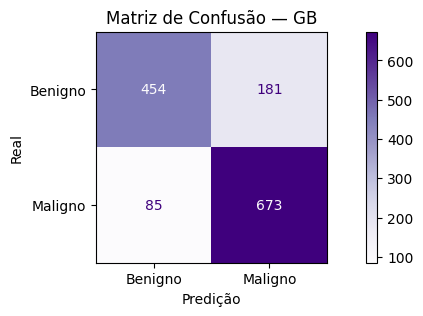

,Precisão,Cobertura,F1-Score
Benigno,0.84,0.71,0.77
Maligno,0.79,0.89,0.83
Exatidão,0.81,0.81,0.81


In [43]:
matriz_confusao(melhor_modelo_gb_no_scaler, X_train, y_train, 'GB')
display_classification_report(melhor_modelo_gb_no_scaler)

O modelo **Gradient Boosting** obteve 81% de exatidão, com boa cobertura para Maligno (0,89) e razoável para benigno (0,71).

## Avaliação do Modelo 

In [44]:
modelo_pred_proba(melhor_modelo_gb_no_scaler, 'submit_gb_no_scaler')

Predição Final por Paciente:


,diagnostico
id,
187,1
188,0
189,0
190,0
191,0
...,...
246,1
247,1
248,1



Contagem de diagnósticos:
  Benigno (0): 30
  Maligno (1): 34


#

# Resultados:

In [45]:
score_publico = [0.727, 0.628, 0.750, 0.727, 0.689]

In [46]:
score_privado = [0.777, 0.702, 0.736, 0.750, 0.800]

In [47]:
submissao_avaliada = ['Sim', 'Não', 'Sim', 'Sim', 'Não']

In [48]:
melhores = pd.DataFrame({
    "Modelo": melhores_modelos_names,
    "F1 Train": melhor_f1_train,
    "F1 Validação": melhores_f1_val,
    "Overfitting": melhores_overfitting,
    "F1 Público": score_publico,
    "Submissão Avaliada": submissao_avaliada,
    "F1 Privado": score_privado
}).set_index("Modelo").sort_values(by="F1 Público", ascending=False)
display(melhores)

,F1 Train,F1 Validação,Overfitting,F1 Público,Submissão Avaliada,F1 Privado
Modelo,,,,,,
rfc,0.805765,0.739394,0.066371,0.750,Sim,0.736
knn,0.808823,0.726586,0.082237,0.727,Sim,0.777
ert,0.799116,0.736359,0.062757,0.727,Sim,0.750
gb,0.856942,0.739191,0.117752,0.689,Não,0.800
svm,0.825475,0.757354,0.068120,0.628,Não,0.702


### **Desempenho dos Melhores Modelos na Validação:**

Os três modelos com melhor desempenho basearam-se nos seguintes resultados de validação:
1. **Standardized SVM (F1 Val: 0.757):** O melhor resultado global. A normalização permitiu que o SVM calculasse margens eficientes entre as classes, mitigando o impacto das discrepâncias de escala nos atributos.
2. **Random Forest (F1 Val: 0.739):** Este comité de peritos demonstrou robustez sem necessidade de scaler, reduzindo a variância ao agregar previsões de diversas árvores construídas via `bootstrap`.
3. **Gradient Boosting (F1 Val: 0.739):** Apresentou uma capacidade preditiva idêntica ao Random Forest, focando-se na redução do enviesamento através da correção iterativa de erros.

### **Desempenho dos Melhores Modelos Públicos (Kaggle):**

A escolha dos modelos para a submissão final no Kaggle baseou-se no equilíbrio entre o desempenho de validação e a capacidade de generalização.

Assim, foram selecionados os modelos **Random Forest**, **Extremely Randomized Trees** e **KNN**:
- **Random Forest (rfc):** Foi o modelo com o melhor desempenho público (0.750). Este resultado valida a eficácia da estratégia de bagging e da seleção aleatória de atributos para reduzir a variância, permitindo que o modelo generalize melhor para dados não vistos do que as árvores de decisão isoladas. O seu baixo nível de overfitting (0.066) reforça a sua robustez/generalização.

- **Extremely Randomized Trees (ert) e KNN:** Estes modelos foram selecionados pela sua elevada consistência. Em ambos os casos, o score de validação (aproximadamente 0.73) foi praticamente idêntico ao score público (0.727). Esta estabilidade indica que os modelos não sofreram de "drenagem de informação" e que as estimativas obtidas por validação cruzada são fiáveis para prever o comportamento em dados futuros.

- **Exclusão do SVM e Gradient Boosting:** Apesar do SVM ter apresentado o melhor score de validação (0.757), o seu desempenho público foi o mais baixo de todos (0.628), sugerindo uma falha na generalização para o conjunto de teste do Kaggle. O Gradient Boosting (gb), por sua vez, apresentou o maior índice de overfitting (0.118), indicando que o modelo se ajustou excessivamente às particularidades do treino, prejudicando a sua performance em dados novos.

**Conclusão Final:** A submissão final priorizou modelos que demonstraram ser robustos e estáveis. A escolha recaiu sobre algoritmos que mantiveram a coerência entre a validação interna e o teste externo na plataforma Kaggle, garantindo que o sucesso no treino não fosse apenas uma memorização de padrões, mas sim uma aprendizagem real capaz de diagnosticar novos casos com precisão.

### **Desempenho dos Modelos Privados (Kaggle):**

A análise dos scores públicos (calculados sobre 50% dos dados de teste) e os scores privados (calculados sobre os restantes dados de teste) permitem retirar conclusões cruciais sobre a generalização dos modelos desenvolvidos.

1. **Robustez e Generalização dos Modelos Selecionados**
   - A escolha em submeter os modelos **KNN**, **ERT** e **RF** provou ser uma estratégia de baixo risco e alta fiabilidade.
   - **KNN** e **Extra Trees (ERT)**: Estes modelos demonstraram uma excelente capacidade de generalização, uma vez que os seus scores melhoraram significativamente no conjunto privado (**KNN:** 0.727 → 0.777; **ERT:** 0.727 → 0.750). Isto indica que a validação cruzada estratificada utilizada foi eficaz em evitar a memorização e capturar padrões reais que se mantiveram consistentes em todo o conjunto de teste.
   - **Random Forest (RF)**: Embora tenha alcançado o score público mais elevado (0.750), a ligeira descida para 0.736 no score privado sugere que o modelo se ajustou a particularidades específicas da primeira metade dos dados de teste e não conseguiu manter a mesma eficácia ao lidar com a totalidade dos dados não observados.

2. **O Caso do Gradient Boosting (GB)**
   - O modelo **GB** obteve o score privado mais elevado (0.800), apesar de ter sido descartado para a submissão final devido ao seu elevado índice de overfitting no treino (0.117).
   - O **Gradient Boosting** é um algoritmo potente que corrige erros sequencialmente, mas que exige uma afinação de hiper-parâmetros cuidadosa para não sofrer de sobre-ajustamento.
   - O seu sucesso no privado indica que, embora parecesse sobre-ajustado nos dados de treino, a sua complexidade permitiu capturar interações não lineares que eram fundamentais nos dados de teste privados do Kaggle.

3. **Falha de Generalização do SVM**
   - O **SVM** apresentou o comportamento mais instável. Apesar de ter o melhor score de validação (0.757), obteve o pior desempenho no teste público (0.628) e privado (0.702). Isto confirma que o **SVM** é extremamente sensível à escala dos dados e aos hiper-parâmetros, visto que mesmo com normalização, a fronteira de decisão criada pode não ter sido representativa da distribuição dos dados de teste reais.

Assim, a comparação mostra que a estabilidade superou a performance pura de treino no **KNN** e **ERT**, que foram os que apresentaram a menor variação e a maior subida de performance entre o público e o privado, garantindo um diagnóstico fiável. O **Gradient Boosting**, embora vencedor em score privado, representava um risco dada a sua má performance no score público e o seu valor de overfitting.

### **Discussão e Conclusões**

A discussão do trabalho centra-se na eficácia da estratégia de validação e na capacidade de generalização dos modelos para o diagnóstico de tumores cerebrais. A utilização de `StratifiedGroupKFold` com 5 pastas foi o pilar fundamental para garantir que instâncias do mesmo paciente não fossem separadas entre treino e validação, **prevenindo a drenagem de informação** e assegurando que as **estimativas de desempenho fossem fiáveis**.

A escolha do `StandardScaler` foi crucial para os modelos geométricos (**KNN** e **SVM**), devido à sensibilidade destes às escalas discrepantes de atributos como o `'med_ADC'`. Em oposição, os comités de árvores (**Random Forest**, **ERT** e **Gradient Boosting**) mostraram-se invariantes à escala, operando através de limiares individuais que tornaram o `scaler` desnecessário ou até prejudicial ao desempenho.

Na análise de resultados, verificou-se que o **SVM**, apesar de liderar no F1 de validação (0.757), falhou na generalização para novos dados. Já o **Gradient Boosting** alcançou o melhor score privado (0.800), mas o seu elevado índice de overfitting (0.117) tornou-o uma escolha arriscada. Os modelos **KNN** e **Extra Trees (ERT)** destacaram-se pela consistência, melhorando os seus scores no conjunto privado, o que comprova que capturaram padrões reais e estáveis.

Conclui-se que a estabilidade superou a performance pura de treino. A seleção final priorizou algoritmos como o **Random Forest**, que equilibrou robustez e baixo sobre-ajustamento. Finalmente, o F1-score validou-se como a métrica de otimização correta, permitindo o equilíbrio clínico essencial entre a precisão do diagnóstico e a cobertura de casos malignos.